# Jupyter - Day 15 - Section 001
# Lecture 15: K-Fold CV for Classification


In [2]:
# Everyone's favorite standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold


# 1. CV for a classification data set
![Palmer Penguins Picture](https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png)

*Artwork by @allison_horst*


For this lab, we are going to use the <a href = "https://allisonhorst.github.io/palmerpenguins/">Palmer Penguins</a> data set by Allison Horst, Alison Hill, and Kristen Gorman. This data set was originally posted in R, but has helpfully been loaded as an easily readable python data set by installing the `palmerpenguins` package using `pip`. 



In [3]:
# You should only have to do this once:
%pip install palmerpenguins

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/miniconda3/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
# If it worked, this should load our dataset
from palmerpenguins import load_penguins
penguins = load_penguins()
penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [12]:
penguins[penguins.isna().any(axis=1)]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN,2007
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN,2007
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN,2007
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN,2007
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN,2007
178,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN,2007
218,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN,2008
256,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN,2009
268,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN,2009


As always, when playing with a new data set, your first job is to just get a feel for what's in the data. We're going to use this data to predict species of the penguin given the other information.

&#9989; **<font color=red>Questions:</font>** 
- How many penguins are in the data set? 
- What are the input variables? 
- What are the possible values of the output variable? 
- Which are categorical varaibales? Which are quantitative? 
- Are there any lines with missing data? How is missing data represented in this data set? 

*344 penguins. Input Variables: 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex', 'year'. Output Variables: 'Adelie', 'Gentoo', 'Chinstrap'. Categorical: 'species', 'island', 'sex'. Quantitative: 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'year'. Missing Value per Column: bill_length_mm: 2. bill_depth_mm: 2. flipper_length_mm: 2. body_mass_g: 2. sex: 11. Missing Data represented with NaN*

&#9989; **<font color=red>Do this:</font>** Spoiler alert, there are penguins with missing data. Replace the `penguins` dataframe with one where you have removed all those lines. (*Hint: this should be a one line operation*)

In [13]:
penguins = penguins.dropna()

Our next favorite thing to do with any data set is to start trying to visualize relationships between the variables. 

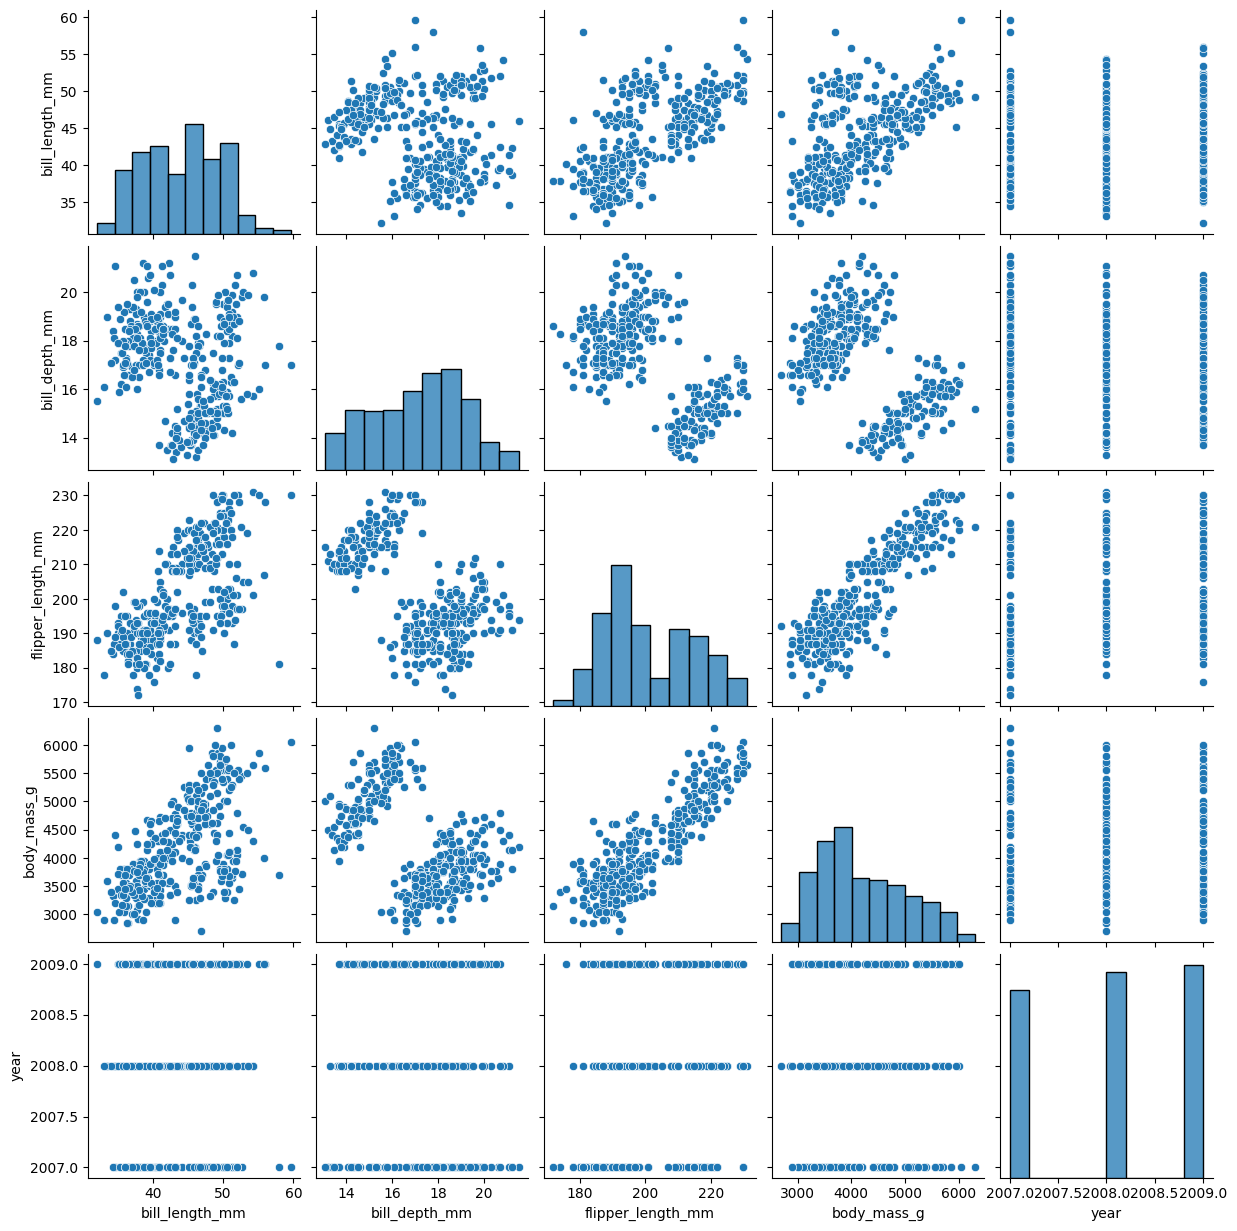

In [14]:
sns.pairplot(penguins)

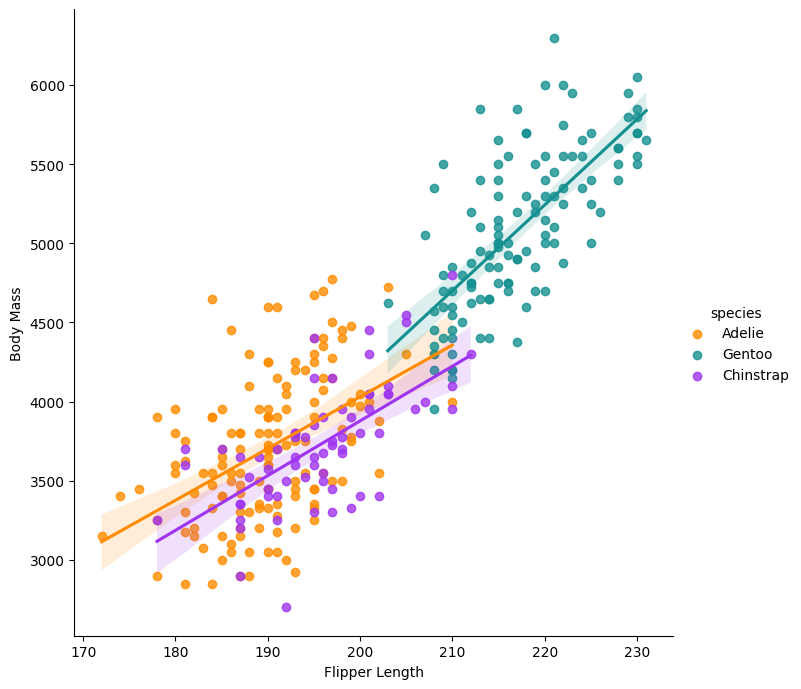

In [15]:
#Here is another nice visualization taken from the palmerpenguins github
g = sns.lmplot(x="flipper_length_mm",
               y="body_mass_g",
               hue="species",
               height=7,
               data=penguins,
               palette=['#FF8C00','#159090','#A034F0'])
g.set_xlabels('Flipper Length')
g.set_ylabels('Body Mass')

## Step 1: Set up your dataframes 

&#9989; **<font color=red>Do this:</font>**  you have your penguins data frame.  
- Build a dataframe $X$ with `island` and `sex` replaced with dummy variable(s)


In [16]:
X = pd.get_dummies(penguins.drop(columns="species"), columns=["island", "sex"])
X.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year,island_Biscoe,island_Dream,island_Torgersen,sex_female,sex_male
0,39.1,18.7,181.0,3750.0,2007,False,False,True,False,True
1,39.5,17.4,186.0,3800.0,2007,False,False,True,True,False
2,40.3,18.0,195.0,3250.0,2007,False,False,True,True,False
4,36.7,19.3,193.0,3450.0,2007,False,False,True,True,False
5,39.3,20.6,190.0,3650.0,2007,False,False,True,False,True


&#9989; **<font color=red>Do this:</font>** Save an pandas series of the entries in `penguins.species` as $y$. 

In [17]:
y = penguins["species"]

## Step 2: Run logistic regression

Ok, you have your penguins data with input variables as X and we are going to predict `penguins.species`. While `scikitlearn` cannot handle input variables that are categorical (hence why we had to put in our dummy variables ourselves), it's fine with a output variable that is. The following code will fit a logistic regression on the whole data set. Of course, you know better than to actually do this to return your results, so in a moment we will be modifying this to get $k$-fold CV test errors. 

In [18]:
logisticmodel = LogisticRegression(max_iter = 1400) # Note, I needed to up the interations
                                                   # to get rid of a convergence warning
logisticmodel.fit(X, y)

/opt/miniconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1400 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1400).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

Also here's some helpful code to remember how to get accuracy/error rates out of classification modules in `scikitlearn`.

In [19]:
# and now we can also get the error rate on the training set. 
from sklearn.metrics import accuracy_score
yhat = logisticmodel.predict(X)
accuracy = accuracy_score(yhat, y)
# Note that accuracy is the percentage correct
print('Accuracy:', accuracy)
# so the percentage incorrect is
print('Error:', 1-accuracy)

# We can get the same info directly from the original model
print('\nAccuracy version 2:', logisticmodel.score(X,y))

Accuracy: 1.0
Error: 0.0

Accuracy version 2: 1.0


&#9989; **<font color=red>Do this:</font>** Ok, your job, should you choose to accept it, is to 
- Train a model predicing `species` from all the input variables using logistic regression. 
- Use $k$-fold cross validation to determine the test error. I would recommend using something like $k=5$ to start building your code, but you can up it to $k=10$ when you want to see better results. 
- *Hint: while I was building my version, I had to set the `max_iter` for Logistic regression pretty high to get the model to converge. However, my error results were still pretty reasonable with lower `max_iter`, ignoring the massive amount of pink warning boxes. Feel free to mess around with this parameter to see how it affects your output.*

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score

logisticmodel = LogisticRegression(max_iter=5000)
logisticmodel.fit(X, y)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_accuracy = cross_val_score(logisticmodel, X, y, cv=kf, scoring="accuracy")

print("Cross-validation accuracies:", cv_accuracy)
print("Mean CV accuracy:", cv_accuracy.mean())
print("CV test error:", 1 - cv_accuracy.mean())

Cross-validation accuracies: [1.         1.         1.         0.98484848 1.        ]
Mean CV accuracy: 0.9969696969696968
CV test error: 0.003030303030303161




-----
### Congratulations, we're done!
Initially developed by Dr. Liz Munch, modified by Dr. Lianzhang Bao and Dr. Firas Khasawneh, Michigan State University

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.